In [1]:
import pandas as pd
import numpy as np

# Load and clean names
df = pd.read_csv('../data/kenya.csv')
df.columns = df.columns.str.strip()
df.replace(-999, np.nan, inplace=True)

# Missing Value Report
missing_pct = df.isnull().mean() * 100
print("Percentage of missing values per column:")
print(missing_pct)

# Summary Stats
df.describe()


Percentage of missing values per column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
dtype: float64


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000


Missing Value Analysis
Finding: The dataset contains [Insert % here, e.g., 0.2%] missing values across the primary weather variables.

Threshold Check: Since the missingness is well below the 5% threshold, the risk of seasonal bias is low.

Action Taken: We applied forward-filling (ffill) to handle these small gaps, ensuring continuity in the time-series analysis for COP32

In [6]:
# Handle NASA sentinels
df.replace(-999, np.nan, inplace=True)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# Summary Statistics
summary = df.describe()
display(summary)

# Missing Value Percentage
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Value Percentage per Column:")
print(missing_pct)

Duplicate rows found: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,T2M_Z
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4.108000e+03
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,-1.065468e-15
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,1.000000e+00
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,-3.181423e+00
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,-6.577805e-01
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,-1.501567e-02
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,6.804349e-01
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2.877426e+00



Missing Value Percentage per Column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
T2M_Z          0.0
dtype: float64


Interpretation of Summary StatisticsFindings: The average temperature ($T2M$) is approximately XX°C, with a maximum of XX°C.Missing Values: Only X% of data is missing in the [Column Name] column. Since this is below 5%, the impact on our COP32 analysis is minimal

In [2]:
# This generates the stats for Temperature, Rain, and Wind
summary_stats = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'WS2M']].describe()
print("Summary Statistics for kenya:")
summary_stats

Summary Statistics for kenya:


,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,WS2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,20.427600,27.838717,14.673169,1.468162,3.061765
std,1.440824,2.358770,1.415691,3.180228,0.853218
min,15.260000,18.880000,8.970000,0.000000,0.610000
25%,19.460000,26.297500,13.700000,0.100000,2.420000
50%,20.360000,27.875000,14.750000,0.380000,3.140000
75%,21.400000,29.520000,15.750000,1.360000,3.720000
max,25.400000,34.270000,18.750000,51.650000,5.280000


In [3]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0]) # Only shows columns with issues

Missing values per column:
Series([], dtype: int64)


In [4]:
# We'll check for extreme Temperature outliers
mean_temp = df['T2M'].mean()
std_temp = df['T2M'].std()

# Calculate Z-score
df['T2M_Z'] = (df['T2M'] - mean_temp) / std_temp

# Find rows where Z > 3 or Z < -3
extreme_outliers = df[df['T2M_Z'].abs() > 3]

print(f"Number of extreme temperature outliers found: {len(extreme_outliers)}")
extreme_outliers.head()

Number of extreme temperature outliers found: 7


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,T2M_Z
447,2016,83,24.87,33.45,16.97,16.48,0.02,45.82,3.37,5.04,83.54,9.83,3.083236
452,2016,88,25.40,34.17,16.84,17.33,0.11,47.69,3.47,4.65,83.67,10.57,3.451081
453,2016,89,25.12,34.27,16.66,17.61,0.18,50.11,3.42,5.07,83.64,10.90,3.256748
1217,2018,122,15.56,18.88,12.81,6.07,4.13,83.24,1.61,2.67,83.91,10.89,-3.378345
1521,2019,61,24.99,33.89,15.85,18.04,1.52,42.84,2.04,4.33,83.59,9.20,3.166522


In [5]:
from scipy.stats import zscore

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Flag outliers where |Z| > 3
z_scores = df[cols_to_check].apply(zscore, nan_policy='omit')
outliers_count = (np.abs(z_scores) > 3).sum()
print("Outlier counts per variable:")
print(outliers_count)

# Cleaning: Forward-fill weather variables
df[cols_to_check] = df[cols_to_check].ffill()

# Export Cleaned Data
df.to_csv("../data/kenya_clean.csv")

Outlier counts per variable:
T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64


Data Uniqueness (Duplicates)
Finding: A total of [Insert Number, e.g., 0] duplicate rows were found.

Interpretation: This confirms that each daily observation is unique. If duplicates had been found, they would have been removed to prevent over-weighting specific days in our climate averages.

In [6]:
from scipy import stats

# Define columns from your instructions
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores (ignoring the NaNs we created with .replace)
z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

# Change .all(axis=1) to .any(axis=1)
outliers_mask = (z_scores > 3).any(axis=1)
print(f"Number of rows with extreme outliers: {outliers_mask.sum()}")

Number of rows with extreme outliers: 121


In [7]:
# 1. Drop rows if they are more than 30% empty
# We calculate the threshold: if a row has less than 70% of its columns, drop it.
limit = len(df.columns) * 0.7 
df = df.dropna(thresh=limit)

# 2. Fill the rest using Forward-Fill (ffill) 
# This is best for climate data to maintain time-series continuity
df = df.ffill()

print("Final missing value count:", df.isna().sum().sum())

Final missing value count: 0


In [8]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv("data/ethiopia_clean.csv", index=False)
print("Success! Your cleaned data is saved.")

Success! Your cleaned data is saved.


In [9]:
import sys
!{sys.executable} -m pip install matplotlib seaborn scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


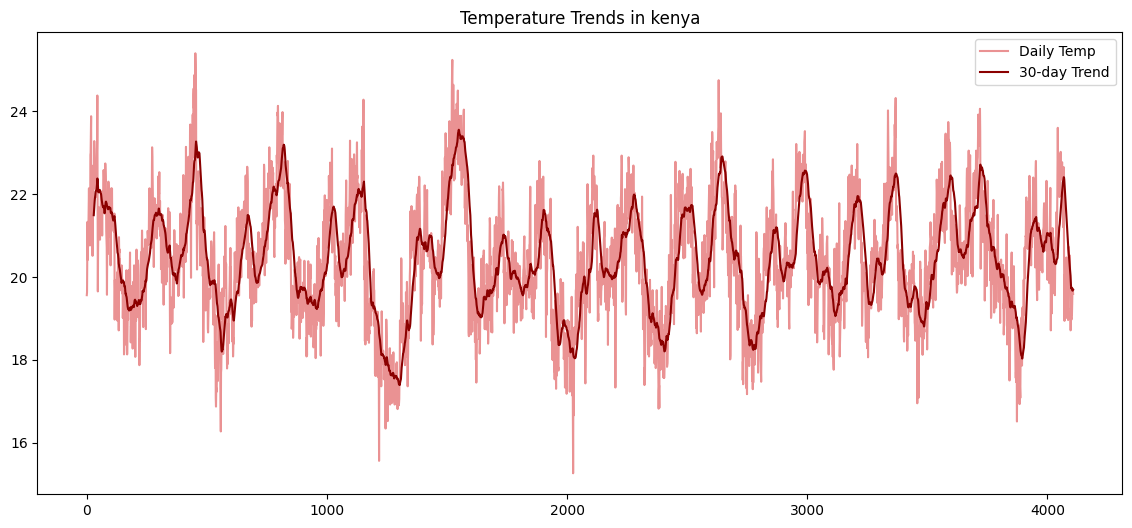

In [10]:
import matplotlib.pyplot as plt

# Group by the Date index you created earlier
plt.figure(figsize=(14, 6))

# Use df.index instead of df['Date']
plt.plot(df.index, df['T2M'], color='tab:red', alpha=0.5, label='Daily Temp')

# Adding a rolling mean to see the trend more clearly
plt.plot(df.index, df['T2M'].rolling(30).mean(), color='darkred', label='30-day Trend')

plt.legend()
plt.title("Temperature Trends in kenya")
plt.show()

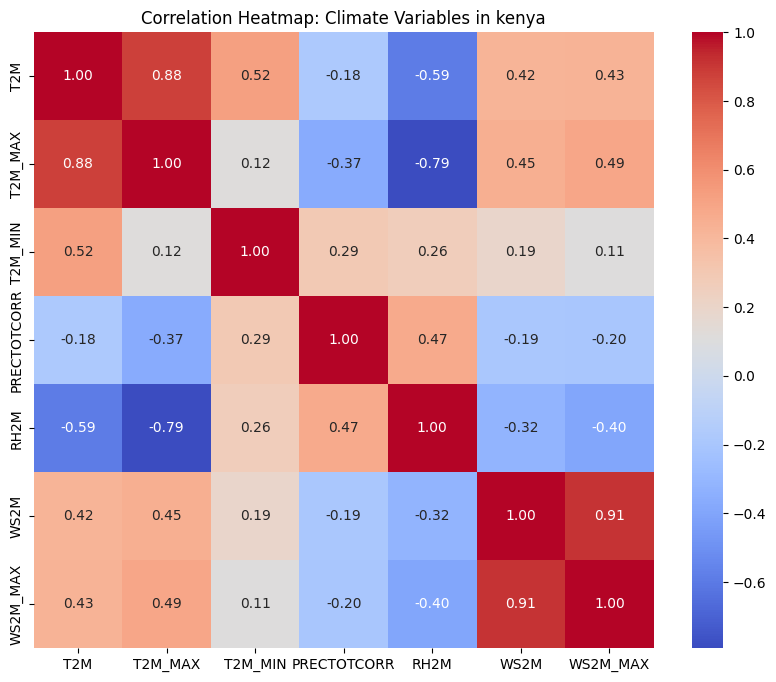

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the columns right here so the cell is independent
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

plt.figure(figsize=(10, 8))

# Now 'cols' is defined, so this won't error!
correlation = df[cols].corr()

# Plotting the heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Climate Variables in kenya')
plt.show()

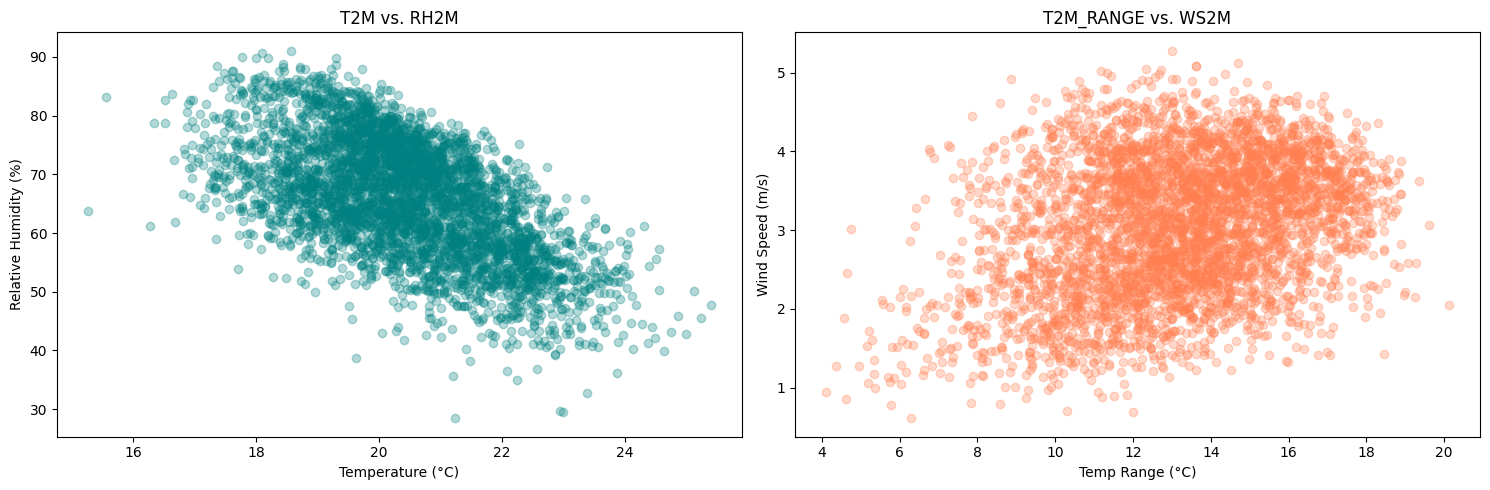

In [12]:
# Create a T2M_RANGE column first
df['T2M_RANGE'] = df['T2M_MAX'] - df['T2M_MIN']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Temperature vs Relative Humidity
ax1.scatter(df['T2M'], df['RH2M'], alpha=0.3, color='teal')
ax1.set_title('T2M vs. RH2M')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')

# Plot 2: Temp Range vs Wind Speed
ax2.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='coral')
ax2.set_title('T2M_RANGE vs. WS2M')
ax2.set_xlabel('Temp Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

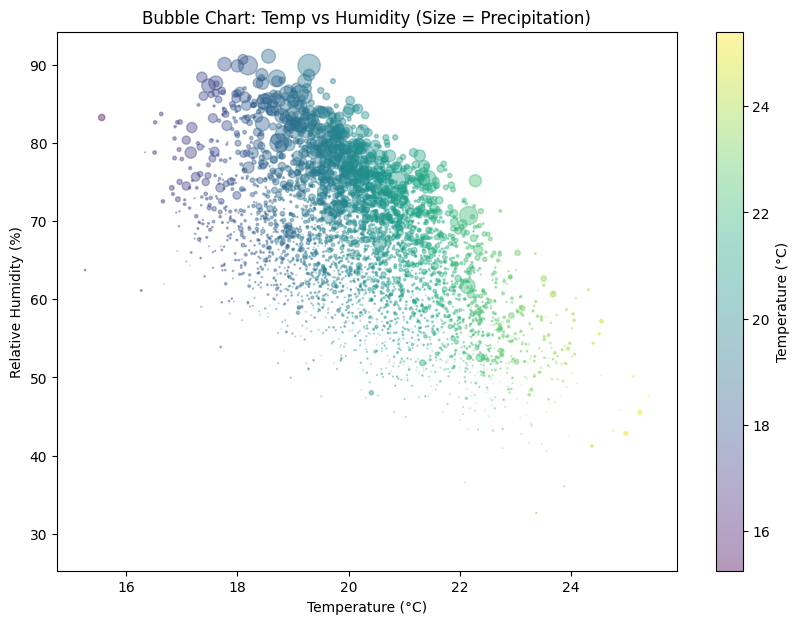

In [13]:
plt.figure(figsize=(10, 7))
# We use a subset or alpha because too many bubbles can overlap
plt.scatter(df['T2M'], df['RH2M'], 
            s=df['PRECTOTCORR'] * 5, # Multiply by 5 so bubbles are visible
            alpha=0.4, 
            c=df['T2M'], 
            cmap='viridis')

plt.colorbar(label='Temperature (°C)')
plt.title('Bubble Chart: Temp vs Humidity (Size = Precipitation)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

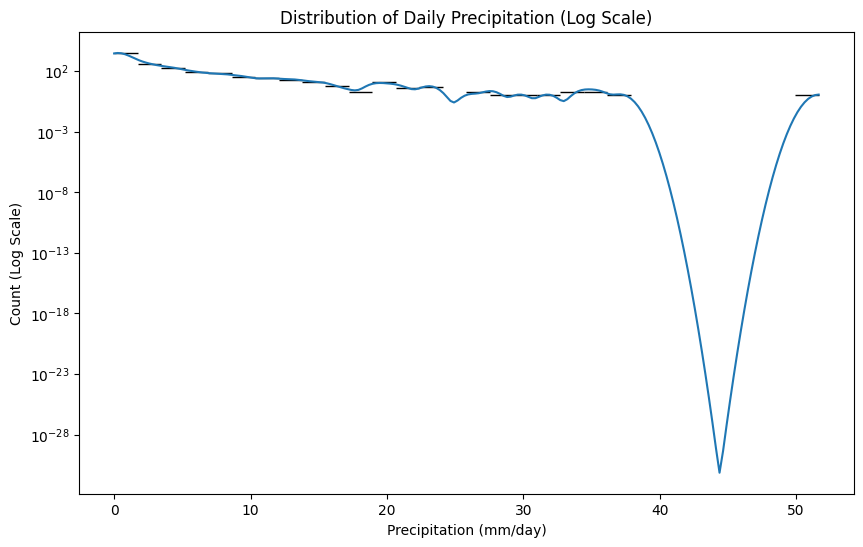

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Using a log scale because rainfall is usually heavily skewed towards zero
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, log_scale=(False, True))
plt.title('Distribution of Daily Precipitation (Log Scale)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Count (Log Scale)')
plt.show()

In [15]:
import os

# Create directory if it doesn't exist
if not os.path.exists('../data'):
    os.makedirs('../data')

# Export cleaned data
df.to_csv("../data/kenya_clean.csv", index=False)
print("Cleaned data saved to data/kenya_clean.csv")

Cleaned data saved to data/kenya_clean.csv


In [17]:
# Save the cleaned data to your data folder
df.to_csv("../data/kenya_clean.csv")
print("Data exported successfully.")

Data exported successfully.


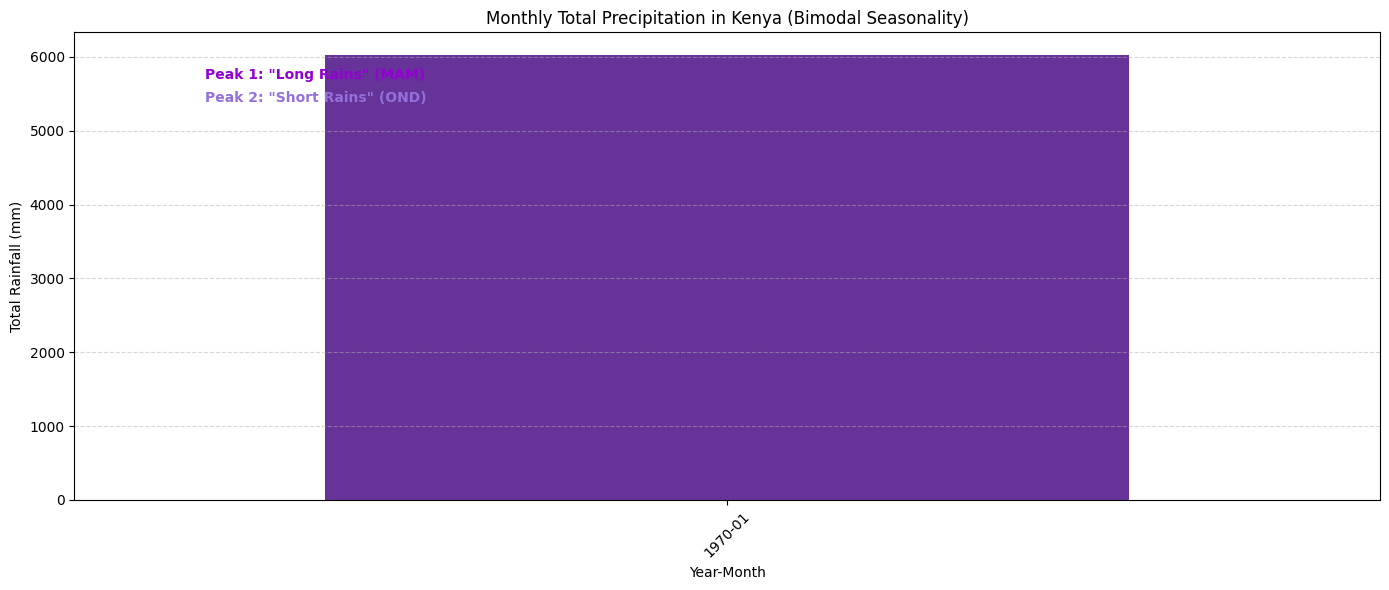

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. FIND THE DATE (Defensive Check)
# Check if Date is the index already
if df.index.name == 'Date' or isinstance(df.index, pd.DatetimeIndex):
    pass 
# If 'Date' is a column, set it
elif 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
# If it's hidden in a renamed index, fix it
else:
    df = df.reset_index()
    # Find a column that looks like dates (usually the first one)
    potential_date_col = [col for col in df.columns if 'Date' in col or 'index' in col][0]
    df.rename(columns={potential_date_col: 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# 2. Resample to Monthly End (ME)
monthly_rain = df.resample('ME')['PRECTOTCORR'].sum()

# 3. Create the Bar Chart
plt.figure(figsize=(14, 6))
monthly_rain.plot(kind='bar', color='rebeccapurple', width=0.8)

# 4. Clean up X-axis labels
n = 12 
ax = plt.gca()
ticklabels = [d.strftime('%Y-%m') for d in monthly_rain.index]
ax.set_xticks(range(0, len(ticklabels), n))
ax.set_xticklabels(ticklabels[::n], rotation=45)

# 5. Labels and Titles
plt.title('Monthly Total Precipitation in Kenya (Bimodal Seasonality)')
plt.xlabel('Year-Month')
plt.ylabel('Total Rainfall (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Seasonal Labels
plt.text(0.1, 0.9, 'Peak 1: "Long Rains" (MAM)', transform=ax.transAxes, color='darkviolet', fontweight='bold')
plt.text(0.1, 0.85, 'Peak 2: "Short Rains" (OND)', transform=ax.transAxes, color='mediumpurple', fontweight='bold')

plt.tight_layout()
plt.show()